# Loading and Preprocessing Dataset

Before training the model, we need to load the dataset and remove the 'Enrolled' students. We are framing this as a binary classification problem to predict strictly between 'Dropout' and 'Graduate'.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb

### Now We Load The Dataset

In [95]:
df = pd.read_csv("../dataset/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

The datasets are loaded perfectly.

# Encoding Target & Features

Because machine learning models cannot understand text directly, we will use Label Encoding to convert our target column into numeric values (0, 1, and 2). Then, we will use One-Hot Encoding to convert the remaining categorical features into dummy variables.

In [97]:
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Target"])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df["Target"].value_counts())

df = pd.get_dummies(df, drop_first=True)

Class mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Target
2    2209
0    1421
1     794
Name: count, dtype: int64


We can see that the text-based categories have been successfully converted into numbers. There are 3 classes in total, so our XGBoost model will perform multiclass classification. Finally, the remaining text features are transformed into numerical dummy variables so the model can easily process them.

# Separating features and target

In [98]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4424, 36)
Target shape: (4424,)


We can see that our dataset is successfully separated into 4,424 input features and target labels.

# Spliting the dataset

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3539, 36)
Testing data: (885, 36)


To prepare for machine learning, this data is divided into two parts, using 80% of the data (3,539 students) to train the model and saving the remaining 20% (885 students) to accurately test its performance.

# Starting Training the Baseline Model (XGBoost)

We will now initialize the XGBoost classifier and train the model using our training data.

In [100]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


# Prediction Generating

In [101]:
y_pred = xgb_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


# Calculate Accuracy

In [102]:
accuracy = accuracy_score(y_test, y_pred)

print(f"XGBoost Accuracy: {accuracy:.4f}")
print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")

XGBoost Accuracy: 0.7616
XGBoost Accuracy: 76.16%


We can see the overall accuracy of the XGBoost classifier on the test dataset.

# Classification Report

In [103]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.73      0.76       284
    Enrolled       0.52      0.42      0.47       159
    Graduate       0.80      0.91      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



# Confusion Matrix

In [104]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[206  33  45]
 [ 39  67  53]
 [ 13  28 401]]


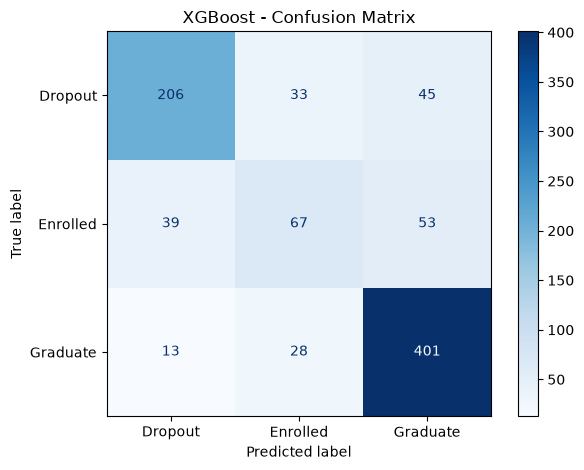

In [105]:
os.makedirs("../results/XGBoost_baseline", exist_ok=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")

plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../results/XGBoost_baseline/confusion_matrix_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Confusion Matrix Observation

We can see from the confusion matrix how the XGBoost model performs across all three student outcomes. Out of the 885 test instances, the model successfully identified the majority of **Graduate** and **Dropout** students. However, similar to the other baseline models, classifying the **Enrolled** students remains relatively challenging due to overlapping characteristics and the class imbalance within the dataset.

# Feature Importance Analyze

Now we extract the feature importance scores from the trained XGBoost model to identify which academic, financial, or demographic factors contribute the most to the prediction.

In [106]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

# Remove any hidden tab characters from feature names
feature_importance["Feature"] = feature_importance["Feature"].str.replace("\t", "")

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.225641
16,Tuition fees up to date,0.100237
22,Curricular units 1st sem (enrolled),0.051517
28,Curricular units 2nd sem (enrolled),0.040307
18,Scholarship holder,0.038463
23,Curricular units 1st sem (evaluations),0.034386
24,Curricular units 1st sem (approved),0.034331
29,Curricular units 2nd sem (evaluations),0.028014
15,Debtor,0.025520
10,Mother's occupation,0.024180


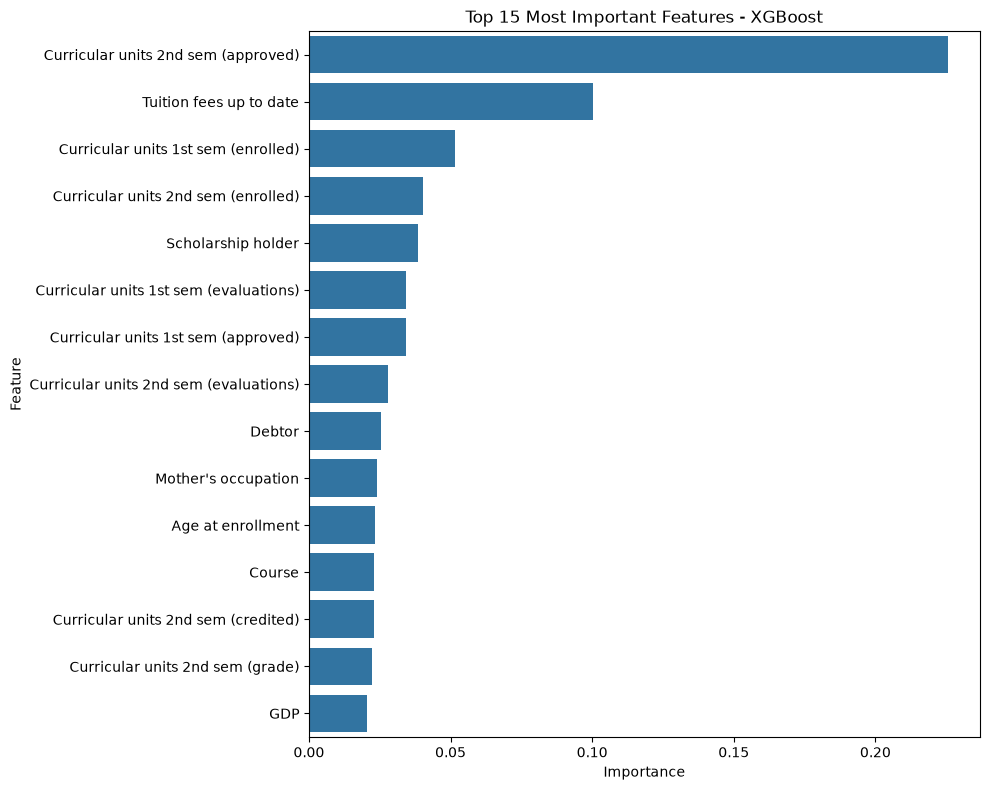

In [107]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features - XGBoost")
plt.tight_layout()

plt.savefig(
    "../results/XGBoost_baseline/feature_importance_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation & Model Summary

In this notebook, we implemented an **XGBoost** classifier as a baseline model for multiclass student outcome prediction (**Dropout**, **Enrolled**, and **Graduate**). After encoding the target variables and splitting the dataset into 80% training (3,539 records) and 20% testing (885 records) sets, the model achieved an overall **Accuracy of 76.16%**[cite: 16]. 

In terms of class-specific performance, the model excelled in identifying **Graduate** students with a **Precision of 0.80**, **Recall of 0.91**, and an **F1-score of 0.85**[cite: 16]. For the **Dropout** class, it also delivered strong results, achieving a **Precision of 0.80**, **Recall of 0.73**, and an **F1-score of 0.76**[cite: 16]. However, predicting the **Enrolled** class remains a challenge (achieving a **Precision of 0.52**, **Recall of 0.42**, and an **F1-score of 0.47**), largely due to minority class representation and overlapping features with the other groups[cite: 16]. 

Furthermore, the feature importance analysis revealed that academic performance in the second and first semesters—specifically **Curricular units 2nd sem (approved)** and **1st sem (enrolled)**—along with financial factors like **Tuition fees up to date**, are the most influential predictors of student retention[cite: 16]. Overall, this XGBoost baseline provides a comprehensive benchmark for comparing our future deep learning (LSTM) and Explainable AI (SHAP) architectures.